In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
import scipy as sc
import scipy.stats as stats
from scipy.signal import find_peaks

sys.path.append('/Users/kjesta/Desktop/LABDATA/Kjersti_100226/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Processed_files/')

from funcs import *
from processing_funcs import *
from analysis_funcs import *
from open_data import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
data = processed_data_20cm

In [67]:
freqs = list(data.keys())
volts = [0.1, 0.2, 0.25, 0.3]
cond = [None, 'p005']

def perform_AnovaRM(freq, cond):
    if freq in [1.1, 1.2, 1.3, 1.4, 1.5]:
        volts = [0.1, 0.2, 0.3]
    else:
        volts = [0.1, 0.2, 0.25, 0.3]

    for v in volts:
        for r in ["R1", "R2", "R3"]:
            df = data[freq][v][cond][r]

            # Extracting free surface elevation data
            eta_P0 = df['P_0'].dropna().values * -1
            eta_P3 = df['P_3'].dropna().values * -1

            # Detect peaks in the free surface elevation data
            threshold = np.sqrt(2)*np.std(eta_P0) - 0.001
            peak_idx_P0 = find_peaks(eta_P0, threshold)[0]
            peak_idx_P3 = find_peaks(eta_P3, threshold)[0]

            # Keep positive amplitudes only
            amp_P0 = []
            for idx in peak_idx_P0:
                amp_P0.append(eta_P0[idx])
            amp_P3 = []
            for idx in peak_idx_P3:
                amp_P3.append(eta_P3[idx])

            amp_P0 = [amp for amp in amp_P0 if amp > 0]
            amp_P3 = [amp for amp in amp_P3 if amp > 0]

            # Need same number of peaks for both conditions to perform ANOVA
            n = min(len(amp_P0), len(amp_P3))
            amp_P0 = amp_P0[:n]
            amp_P3 = amp_P3[:n]

            subjects = np.arange(1, n + 1)

            df_long = pd.DataFrame({
            'subject': np.concatenate([subjects, subjects]),
            'probe':   np.concatenate([np.repeat('P_0', n), np.repeat('P_3', n)]),
            'amplitude': np.concatenate([amp_P0, amp_P3])})

            print(f"ANOVA for freq={freq} Hz, voltage={v} V, condition={cond}, run={r}:")
            print(df_long.head())    

In [68]:
perform_AnovaRM(1.1, None)

ANOVA for freq=1.1 Hz, voltage=0.1 V, condition=None, run=R1:
   subject probe  amplitude
0        1   P_0    0.00438
1        2   P_0    0.00438
2        3   P_0    0.00472
3        4   P_0    0.00404
4        5   P_0    0.00387
ANOVA for freq=1.1 Hz, voltage=0.1 V, condition=None, run=R2:
   subject probe  amplitude
0        1   P_0   0.004703
1        2   P_0   0.004953
2        3   P_0   0.004703
3        4   P_0   0.004103
4        5   P_0   0.003753
ANOVA for freq=1.1 Hz, voltage=0.1 V, condition=None, run=R3:
   subject probe  amplitude
0        1   P_0   0.004386
1        2   P_0   0.004736
2        3   P_0   0.004556
3        4   P_0   0.004216
4        5   P_0   0.004386
ANOVA for freq=1.1 Hz, voltage=0.2 V, condition=None, run=R1:
   subject probe  amplitude
0        1   P_0   0.009246
1        2   P_0   0.009586
2        3   P_0   0.008556
3        4   P_0   0.009246
4        5   P_0   0.009246
ANOVA for freq=1.1 Hz, voltage=0.2 V, condition=None, run=R2:
   subject probe  

In [ ]:
eta0 = data[1.4][0.3][None]["R1"]['P_0'].dropna().values
eta3 = data[1.4][0.3][None]["R1"]['P_3'].dropna().values

eta0 = eta0 * -1
eta3 = eta3 * -1

peak_idx = find_peaks(eta0, 0.015)
amp0 = []
for idx in peak_idx[0]:
    amp0.append(eta0[idx])

peak_idx = find_peaks(eta3, 0.015)
amp3 = []
for idx in peak_idx[0]:
    amp3.append(eta3[idx])

# Only keep positive peaks
amp0 = [amp for amp in amp0 if amp > 0]
amp3 = [amp for amp in amp3 if amp > 0]

# Put into dataframe to perform AnovaRM
# Dataframe must be in long format, with columns for subject, condition, and value


In [5]:
from statsmodels.stats.anova import AnovaRM

In [ ]:
print(AnovaRM(data=df, depvar='response', subject='patient', within=['drug']).fit())

In [51]:
def summarize_distribution(x):
    from scipy import stats
    import numpy as np

    d = stats.describe(x, nan_policy='omit')
    std = np.sqrt(d.variance)

    print(f"n = {d.nobs}")
    print(f"Range: {d.minmax[0]} to {d.minmax[1]}")
    print(f"Mean = {d.mean:.3f}, Std = {std:.3f}")
    print(f"Skewness = {d.skewness:.3f}")
    print(f"Kurtosis (Fisher) = {d.kurtosis:.3f}")

    # Simple textual interpretation
    if abs(d.skewness) < 0.5:
        print("Shape: roughly symmetric")
    elif d.skewness > 0:
        print("Shape: right-skewed (long right tail)")
    else:
        print("Shape: left-skewed (long left tail)")

    if d.kurtosis > 0.5:
        print("Tails: heavier than normal (more outliers)")
    elif d.kurtosis < -0.5:
        print("Tails: lighter than normal (flatter, fewer extremes)")
    else:
        print("Tails: similar to normal")

In [52]:
summarize_distribution(x)

n = 10578
Range: -0.0117778899602949 to 0.011362110039705
Mean = 0.000, Std = 0.008
Skewness = 0.001
Kurtosis (Fisher) = -1.482
Shape: roughly symmetric
Tails: lighter than normal (flatter, fewer extremes)


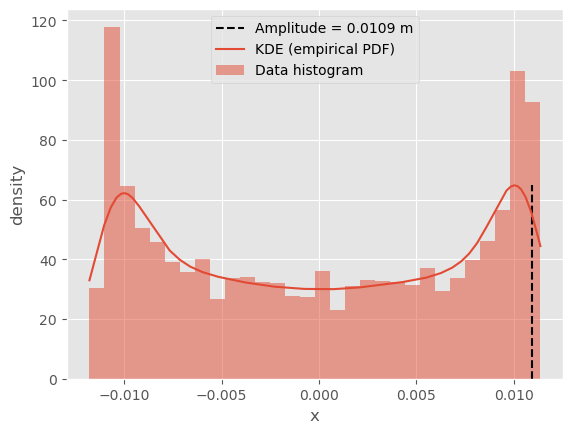

In [55]:
# KDE estimate
kde = stats.gaussian_kde(x)
xs = np.linspace(x.min(), x.max(), 400)
pdf_kde = kde(xs)

std = np.sqrt(results.variance)
var_amp = np.sqrt(2)*std

plt.figure()
plt.vlines(var_amp, ymin=0, ymax=max(pdf_kde.max(), pdf_norm.max()), color='k', linestyle='--', label=f"Amplitude = {var_amp:.3g} m")
plt.plot(xs, pdf_kde, label="KDE (empirical PDF)")
plt.hist(x, bins=30, density=True, alpha=0.5, color='C0', label="Data histogram")
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.show()

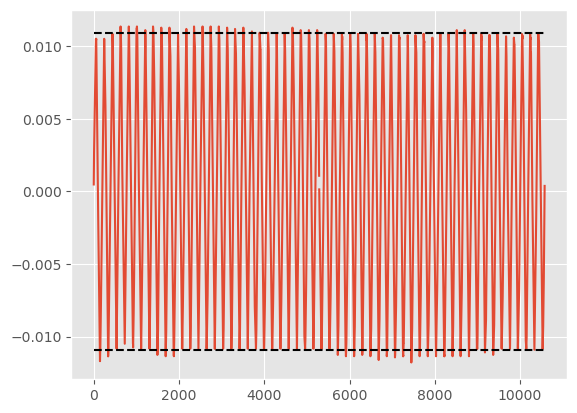

In [54]:
std = np.sqrt(results.variance)
var_amp = np.sqrt(2)*std

plt.plot(x)
plt.hlines(var_amp, xmin=0, xmax=len(x), color='k', linestyle='--', label=f"Amplitude = {var_amp:.3g} m")
plt.hlines(-var_amp, xmin=0, xmax=len(x), color='k', linestyle='--')

In [56]:
P0 = data[1.3][0.2][None]["R1"]['P_0'].dropna().values
P3 = data[1.3][0.2][None]["R1"]['P_3'].dropna().values

In [59]:
stat, p = stats.levene(P0, P3)
print(f"Levene's test statistic: {stat:.5f}, p-value: {p:.5f}")

Levene's test statistic: 18.50861, p-value: 0.00002
